In [1]:
import polars as pl
import numpy as np
from pathlib import Path

from dataclasses import dataclass
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, balanced_accuracy_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, SGDRegressor, RidgeClassifier

In [17]:
@dataclass
class ModelData:
    data = {"train": None, "test": None, "val": None}

    def load_data(self, split, files):
        data_frames = []
        for file in files:
            df = pl.read_parquet(Path(f"data/prepared/{file}.parquet"))
            df = df.drop(["raw_t_ms", "t_ms", "acc_norm"]).rename({"drink": "sip"})
            data_frames.append(df)

        self.data[split] = pl.concat(data_frames) if data_frames else pl.DataFrame()

In [18]:
split = {"train": ["g_v01", "g_v01_1", "g_ws0", "g_ws2"], "val": ["g_v02", "g_ws2_val", "g_ws1"], "test": ["g_v04", "g_v03", "g_ws2_1"]}
#split = {"train": ["g_ws0", "g_ws2", "g_ws2_val", "g_ws2_1",  "g_ws1"]}

model_data = ModelData()
for split_name, files in split.items():
    model_data.load_data(split_name, files)

print(model_data.data)

{'train': shape: (24_381, 7)
┌───────┬───────┬───────┬────────┬────────┬────────┬─────┐
│ acc_x ┆ acc_y ┆ acc_z ┆ gyro_x ┆ gyro_y ┆ gyro_z ┆ sip │
│ ---   ┆ ---   ┆ ---   ┆ ---    ┆ ---    ┆ ---    ┆ --- │
│ f64   ┆ f64   ┆ f64   ┆ f64    ┆ f64    ┆ f64    ┆ i64 │
╞═══════╪═══════╪═══════╪════════╪════════╪════════╪═════╡
│ 1.02  ┆ 0.95  ┆ 9.43  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 0   │
│ 1.02  ┆ 0.94  ┆ 9.46  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 0   │
│ 1.04  ┆ 0.93  ┆ 9.41  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 0   │
│ 1.01  ┆ 0.96  ┆ 9.43  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 0   │
│ 1.02  ┆ 0.94  ┆ 9.44  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 0   │
│ …     ┆ …     ┆ …     ┆ …      ┆ …      ┆ …      ┆ …   │
│ 1.11  ┆ 0.64  ┆ 9.44  ┆ -0.08  ┆ 0.04   ┆ -0.02  ┆ 0   │
│ 0.99  ┆ 0.65  ┆ 9.52  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 0   │
│ 0.98  ┆ 0.61  ┆ 9.41  ┆ -0.08  ┆ 0.04   ┆ -0.01  ┆ 0   │
│ 0.98  ┆ 0.52  ┆ 9.42  ┆ -0.09  ┆ 0.03   ┆ -0.01  ┆ 0   │
│ 0.97  ┆ 0.61  ┆ 9.58  ┆ -0.07  ┆ 0.04   ┆ -0.02  ┆ 0   │
└───────┴───────┴───────┴──

In [24]:
ss = "train"
print(model_data.data[ss]["raw_t_ms"].sum()/1000/60)
print(model_data.data[ss].filter(pl.col("drink") == 1)["raw_t_ms"].sum()/1000/60)

47.369
0.0


Text(0.5, 1.0, 'Matriz de correlação')

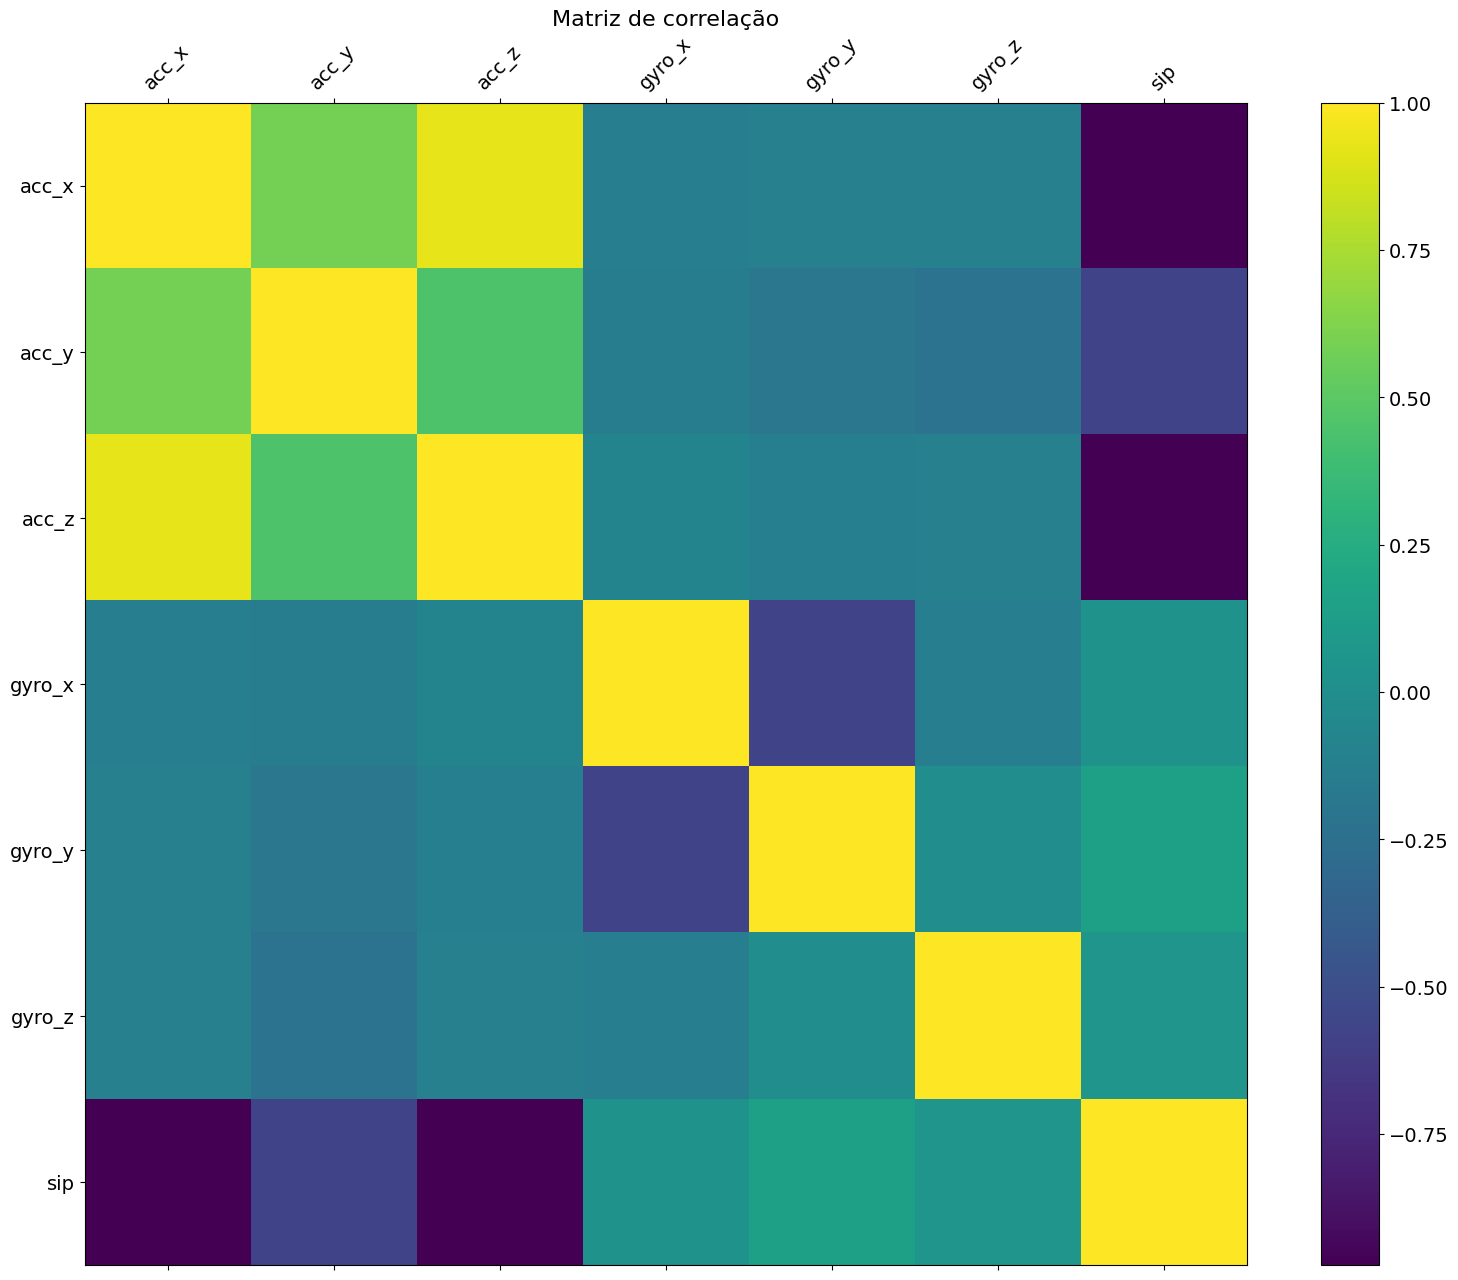

In [19]:
import matplotlib.pyplot as plt

df = model_data.data["train"].corr().to_pandas()
f = plt.figure(figsize=(19, 15))
plt.matshow(df.corr(), fignum=f.number)
plt.xticks(
    range(df.select_dtypes(["number"]).shape[1]),
    df.select_dtypes(["number"]).columns,
    fontsize=14,
    rotation=45,
)
plt.yticks(
    range(df.select_dtypes(["number"]).shape[1]),
    df.select_dtypes(["number"]).columns,
    fontsize=14,
)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title("Matriz de correlação", fontsize=16)

## Models

In [3]:
def mae(y_true, y_pred):
    return np.abs(y_true - y_pred).mean()


def rmse(y_true, y_pred):
    return np.sqrt(np.pow(y_true - y_pred, 2).mean())


def accuracy(y_true, y_pred):
    return (y_true == y_pred).sum() / len(y_pred)

def sigmoid(x):
    return 1/(1 + np.exp(-x))


class ModelClass:
    def __init__(self, data):
        self.model = None
        self.models = {
            "linear": LinearRegression(),
            "logistic": LogisticRegression(random_state=16),
            "ridge": Ridge(),
            "ridge_cv": RidgeCV(),
            "SGDRegressor": SGDRegressor(),
            "ridge_classifier": RidgeClassifier(),
        }
        self.train_data = data["train"]
        
        del data["train"]
        self.data = data
        self.filter_columns = None

    def training(self, model_type: str = "linear", print_coef: bool = False):
        y = self.train_data[["drink"]].to_numpy()

        if self.filter_columns is not None:
            X = self.train_data[self.filter_columns].to_numpy()
        else:
            X = self.train_data.drop("drink").to_numpy()

        self.model = self.models[model_type]
        self.model.fit(X, y.ravel())

        # print(f"Model trained with score: {self.model.score(X, y):.2f}")
        if print_coef:
            print(f"slope: {self.model.coef_}")
            print(f"intercept: {self.model.intercept_}")

        return self.model.score(X, y)

    def predict(self, split: str = "test"):
        if self.filter_columns is not None:
            X = self.data[split][self.filter_columns].to_numpy()
        else:
            X = self.data[split].drop("drink").to_numpy()

        return self.model.predict(X).flatten()

    def evaluate(self, predicted, split: str = "test", treshold: float = 0.65, plot: bool = False):
        predicted = sigmoid(predicted)
        predicted = np.where(predicted <= treshold, 0, predicted)
        predicted = np.where(predicted > treshold, 1, predicted)

        test_y = self.data[split]["drink"].to_numpy()

        if plot:
            f = plt.figure(figsize=(16, 9))
            plt.plot(predicted)
            plt.plot(test_y)
            
            plt.show()
            plt.close()

            cf_matrix = confusion_matrix(test_y, predicted)
            cm_display = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=["Não gole", "Gole"])
            cm_display.plot()
            plt.show()
            plt.close()

        results = {
            "mae": mae(test_y, predicted),
            "accuracy": accuracy(test_y, predicted),
            "rmse": rmse(test_y, predicted),
            "treshold": treshold,
            "precision": balanced_accuracy_score(test_y, predicted),
            "recall": recall_score(test_y, predicted),
            "specificity": recall_score(test_y, predicted, pos_label=0),
            #"f1_score": f1_score(test_y, predicted),
        }

        return results
    
    def main(self, model_type, cols, plot = False):
        self.filter_columns = cols
        score = self.training(model_type=model_type, print_coef=plot)

        # Validation
        predicted_val = self.predict(split="val")
        best_thres, best_accuracy = 0, 0 
        for thres_x in np.arange(0.5, 1, 0.001):
            current_accuracy = self.evaluate(predicted_val, treshold=thres_x, split="val")["accuracy"]

            if current_accuracy >= best_accuracy:
                best_accuracy = current_accuracy
                best_thres = thres_x

        # test
        result = self.evaluate(self.predict(), plot=plot, treshold=best_thres)
        
        result["score"] = score
        return result

In [6]:
model_class = ModelClass(model_data.data.copy())

test_clomuns = {
    "all": None,
    "all_acc_gyro": ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"],
    "best_corr": ["acc_x", "acc_z", "gyro_y"],
    "simple": ["acc_x", "gyro_y"],
    "simple2": ["acc_x", "gyro_y", "gyro_x"],
    "all_gyros_acc_x": ["acc_x", "gyro_y", "gyro_z", "gyro_x"],
    "all_acc_and_gyro_y": ["acc_x", "acc_y", "acc_z", "gyro_y"],
}

final_results = []
for m in model_class.models.keys():
    for label, cols in test_clomuns.items():
        result = model_class.main(model_type=m, cols=cols)

        result["label"] = label
        result["model"] = m
        final_results.append(result)
        # print(f"Results for {label}: {result}")

pl.DataFrame(final_results).sort(["recall", "accuracy", "rmse"], descending=[True, True, False])

mae,accuracy,rmse,treshold,precision,recall,specificity,score,label,model
f64,f64,f64,f64,f64,f64,f64,f64,str,str
0.04596,0.95404,0.214383,0.57,0.884593,0.784504,0.984683,0.553015,"""simple""","""ridge_cv"""
0.04596,0.95404,0.214383,0.57,0.884593,0.784504,0.984683,0.553015,"""simple""","""linear"""
0.04596,0.95404,0.214383,0.57,0.884593,0.784504,0.984683,0.553015,"""simple""","""ridge"""
0.045219,0.954781,0.212647,0.573,0.884039,0.782082,0.985996,0.551768,"""simple""","""SGDRegressor"""
0.041142,0.958858,0.202834,0.584,0.885454,0.779661,0.991247,0.541383,"""all_gyros_acc_x""","""SGDRegressor"""
…,…,…,…,…,…,…,…,…,…
0.077094,0.922906,0.277658,0.731,0.749176,0.498789,0.999562,0.993109,"""all_acc_and_gyro_y""","""logistic"""
0.077094,0.922906,0.277658,0.731,0.749176,0.498789,0.999562,0.992904,"""all_acc_gyro""","""logistic"""
0.081913,0.918087,0.286204,0.731,0.732446,0.464891,1.0,0.993479,"""all_acc_and_gyro_y""","""ridge_classifier"""


In [16]:
pl.DataFrame(final_results).sort(["recall", "accuracy", "rmse"], descending=[True, True, False])["rmse"].round(4).to_arrow()

[
  0.2144,
  0.2144,
  0.2144,
  0.2126,
  0.2028,
  0.217,
  0.2204,
  0.2204,
  0.2204,
  0.2082,
  ...
  0.2756,
  0.2736,
  0.2777,
  0.2777,
  0.2763,
  0.2777,
  0.2777,
  0.2862,
  0.2888,
  0.2964
]

slope: [-0.06297311  0.02817046]
intercept: 0.0635120170557861


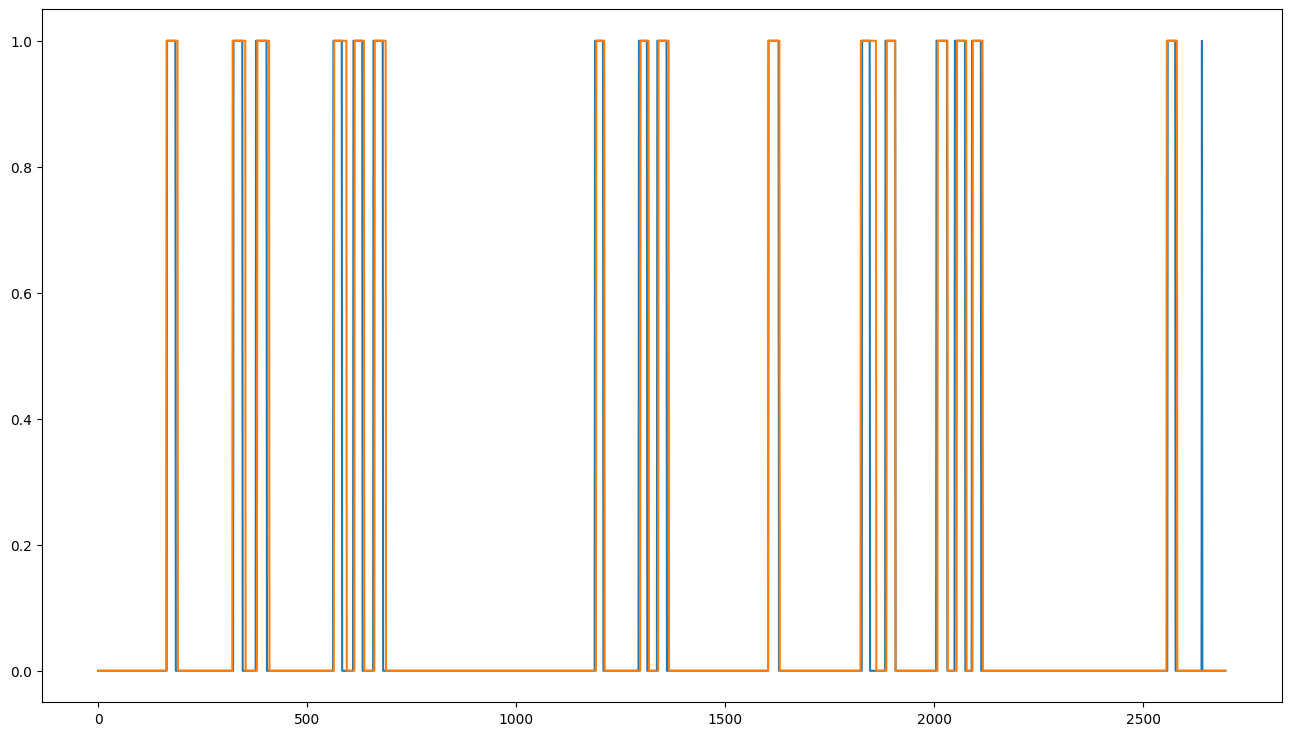

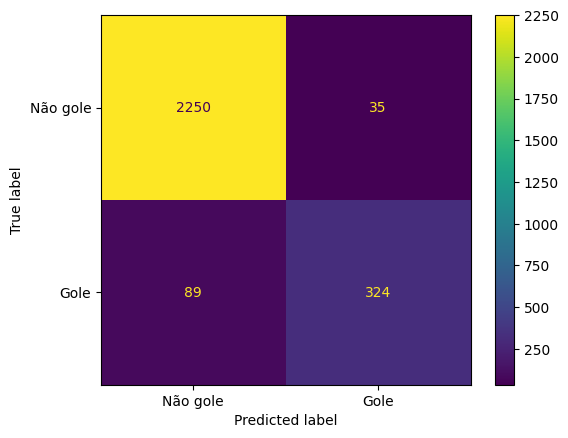

{'mae': np.float64(0.04595997034840623),
 'accuracy': np.float64(0.9540400296515937),
 'rmse': np.float64(0.21438276597806605),
 'treshold': np.float64(0.5700000000000001),
 'precision': 0.8845931726545901,
 'recall': 0.784503631961259,
 'specificity': 0.9846827133479212,
 'score': 0.5530148877451528}

In [34]:
model_class.main(model_type="linear", cols=test_clomuns["simple"], plot=True)

# Real test

In [5]:
df = pl.read_csv(
    "/mnt/c/Users/rafac/Documents/VS/IA369/arduino_smart_bottle/model/data/raw/B_A.TXT",
    new_columns=[
        "raw_t_ms",
        "acc_x",
        "gyro_y",
        "drink",
        "model"
    ],
    has_header=False,
)

# Drop columns with all null values
df = df[[s.name for s in df if not (s.null_count() == df.height)]]

label = df["drink"].to_numpy()
model_value = df["model"].to_numpy()
results = {
    "mae": mae(label, model_value),
    "accuracy": accuracy(label, model_value),
    "rmse": rmse(label, model_value),
    "precision": balanced_accuracy_score(label, model_value),
    "recall": recall_score(label, model_value),
    "specificity": recall_score(label, model_value, pos_label=0),
    #"f1_score": f1_score(test_y, predicted),
}
results

{'mae': np.float64(0.04265402843601896),
 'accuracy': np.float64(0.957345971563981),
 'rmse': np.float64(0.20652851724645427),
 'precision': 0.9358515683501123,
 'recall': 0.8865546218487395,
 'specificity': 0.9851485148514851}